# Week 7 - Function 7 ((36DP, 6D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np
import torch
import gpytorch

from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_6D_blackbox_analysis,
    plot_output_outliers,
    plot_bar_diff,
    plot_nd_mean_uncertainty_slice,
    plot_nd_svm_analysis_slice,
    plot_nd_acquisition_comparison_slice
)

In [2]:
# ── GPyTorch utilities (shared across migrated notebooks) ──────────────────────

class MaternARD_ExactGP(gpytorch.models.ExactGP):
    def __init__(self, X, y, likelihood, n_dims, ls_prior=None):
        super().__init__(X, y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        ls_prior = ls_prior or gpytorch.priors.GammaPrior(3.0, 6.0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, ard_num_dims=n_dims,
                lengthscale_prior=ls_prior
            ),
            outputscale_prior=gpytorch.priors.GammaPrior(2.0, 0.15)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def fit_gpytorch_model(X_np, y_np, n_dims, noise=0.01, n_steps=300, lr=0.1, ls_prior=None):
    X_t = torch.tensor(X_np, dtype=torch.float64)
    y_t = torch.tensor(y_np, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    likelihood.noise = noise
    model = MaternARD_ExactGP(X_t, y_t, likelihood, n_dims, ls_prior=ls_prior).double()
    likelihood = likelihood.double()
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = -mll(model(X_t), y_t)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    model.eval(); likelihood.eval()
    return model, likelihood, losses


def gp_predict(model, likelihood, X_np):
    """Drop-in replacement for sklearn GP.predict(X, return_std=True)."""
    X_t = torch.tensor(X_np, dtype=torch.float64)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(X_t))
    return pred.mean.numpy(), pred.variance.sqrt().numpy()


def gp_converged_gpytorch(losses, min_loss_drop=0.1, max_final_loss=10.0):
    losses_arr = np.array(losses)
    loss_drop = losses_arr[0] - losses_arr[-1]
    converged = (not np.any(np.isnan(losses_arr))
                 and loss_drop >= min_loss_drop
                 and losses_arr[-1] < max_final_loss)
    return converged, {'loss_drop': loss_drop, 'final_loss': losses_arr[-1]}


# Plan
We now have ((36, 6)) — 36 data points, 6 dimensions, from `./data/week_7/function_7/`.

**Architecture**: Dual-GP ensemble (QT + log10) with SVM-constrained UCB.

**Key decisions** (carried forward):
- QuantileTransformer + log10 shift: outlier spikes (y ∈ [0.003, 1.61])
- SVM C=1 soft margin, median threshold, fail-safe at <5% coverage
- x3 identified as noise dim — LHS in 5D active subspace [x1,x2,x4,x5,x6]; x3 fixed at training mean

**Week 7 fixes:**
- **Noise detection recalibrated**: GPyTorch GammaPrior(3,6) regularises all ls < 2.0, so the old absolute threshold (100) never fires. Replaced with relative threshold: ls > mean + 2×std. Fallback to x3 (index 2) preserved — Week 5 sklearn ARD confirmed x3 is noise (ls=438,000).
- kappa=3.846 (budget-aware: week 7/13); 50K LHS candidates in 5D active space

**Steps:** Load data → Preprocessing → GP models (full 6D ARD, identifies x3 as noise) → SVM → Acquisition (5D active subspace) → Report

# 1. Load data

In [3]:
X_train_raw = np.load(r"./data/week_7/function_7/inputs.npy")
y_train_raw = np.load(r"./data/week_7/function_7/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(36, 6), y=(36,)
X range: [0.0036, 0.9987]
y range: [2.70e-03, 2.86e+00]


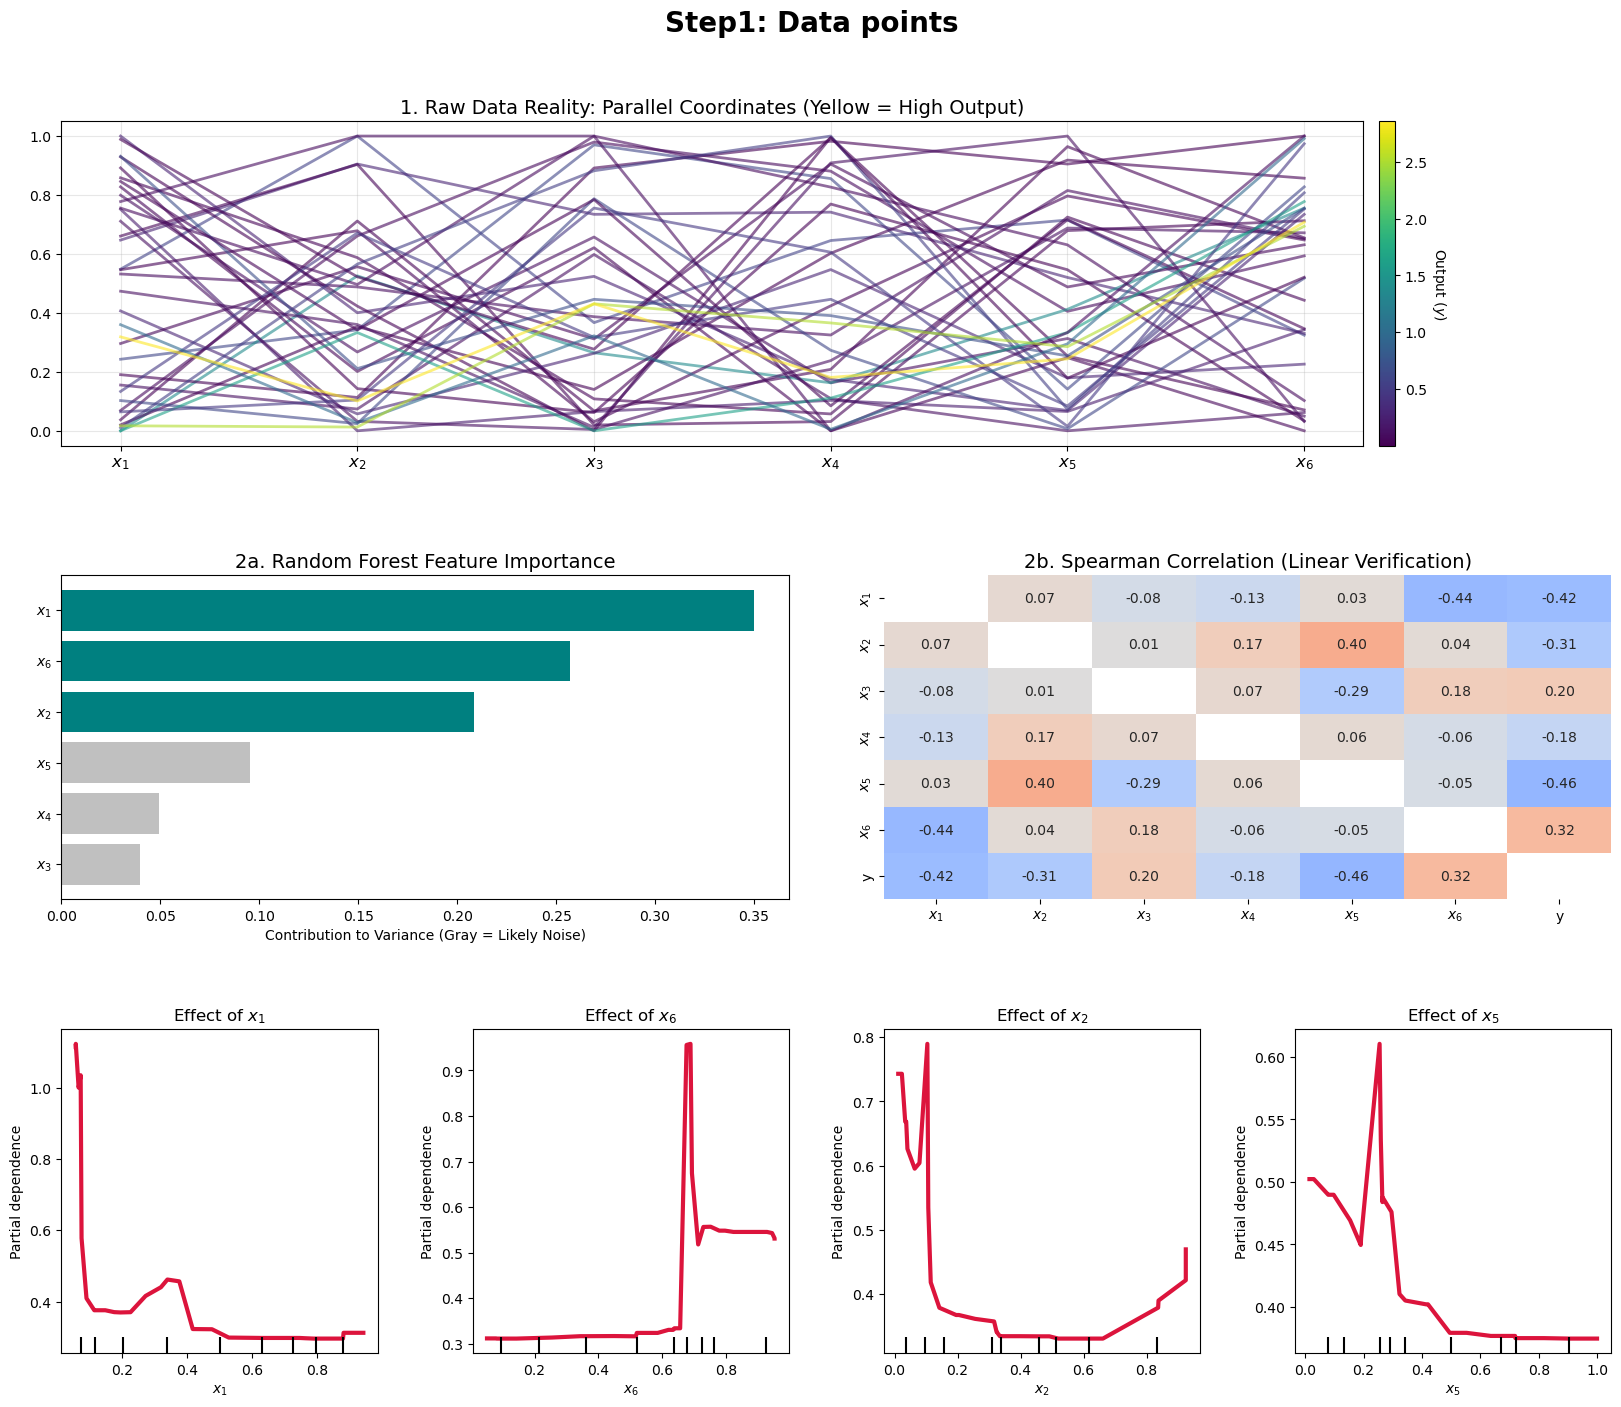

In [4]:
plot_6D_blackbox_analysis(X_train_raw, y_train_raw, "Step1: Data points", f"""
DATA SUMMARY
{'='*30}
Points: {len(X_train_raw)}
Input shape: {X_train_raw.shape}
Output shape: {y_train_raw.shape}

CURRENT BEST
{'='*30}
Current best: {np.max(y_train_raw)}
At input: {X_train_raw[np.argmax(y_train_raw)]}
""")

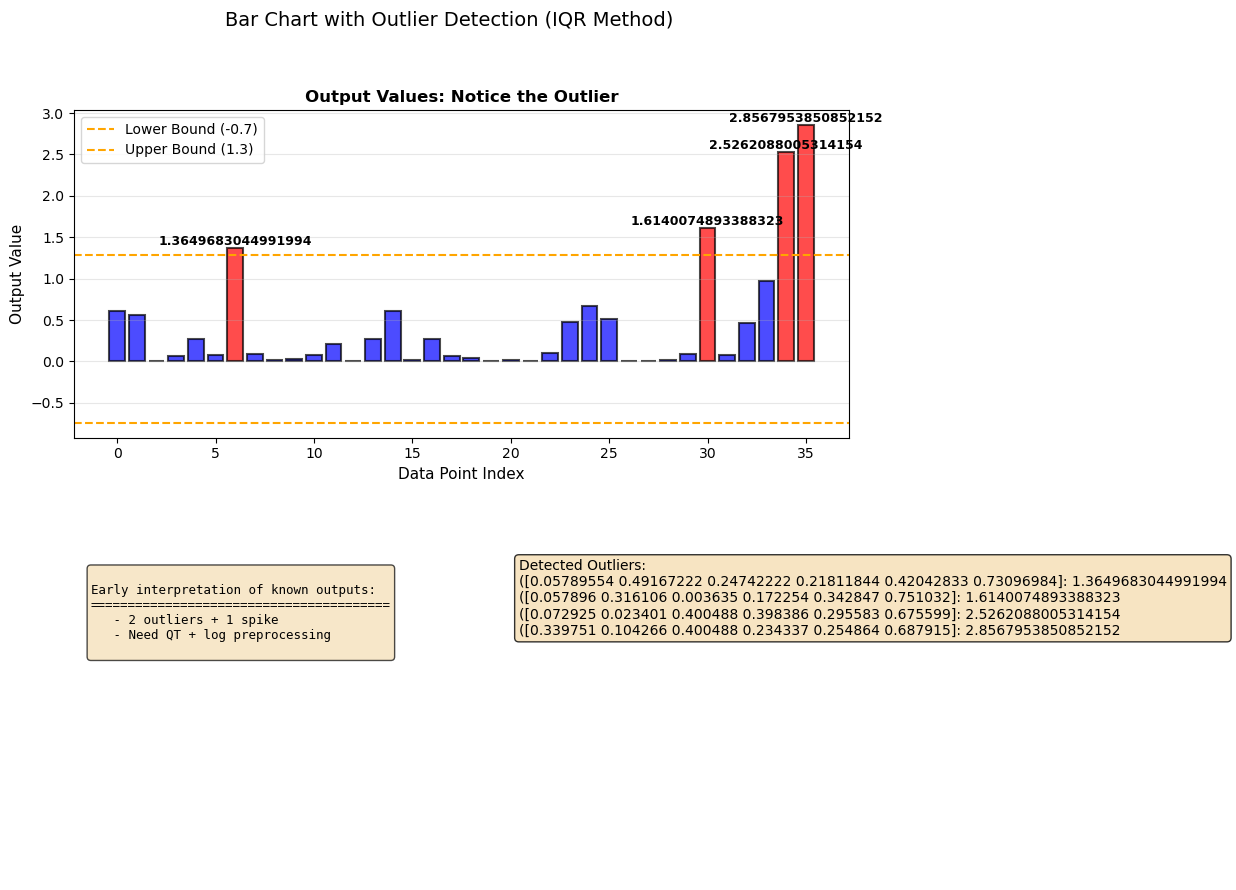

In [5]:
plot_output_outliers(X_train_raw, y_train_raw, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*40}
   - 2 outliers + 1 spike
   - Need QT + log preprocessing
""")

# 2. Preprocessing

Output has outlier spikes. Using QuantileTransformer + log10 shift.

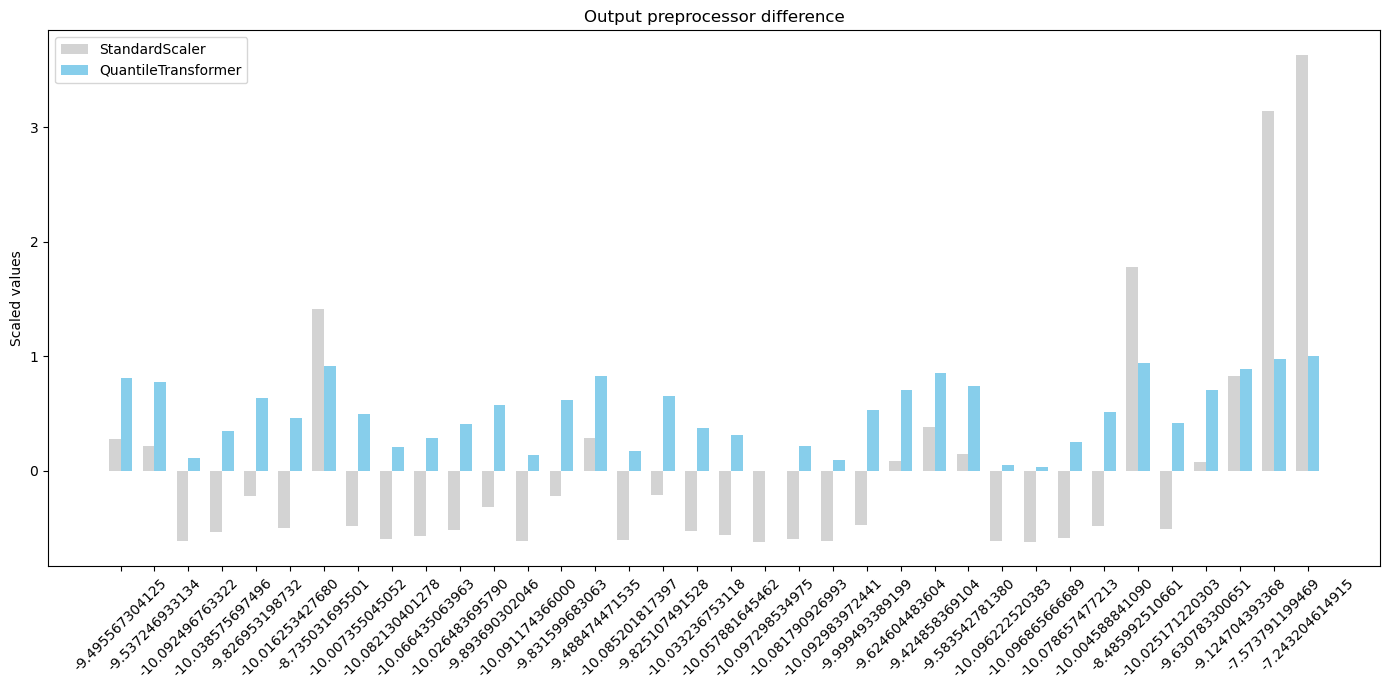

Total points: 36
QT range: [0.0, 1.0]

Log shift constant: 1.00
All 36 points included in log space
log10(y_shifted) range: [0.0023, 0.5865]


In [6]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

from sklearn.preprocessing import StandardScaler
scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer',
              'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"QT range: [{y_qt.min():.1f}, {y_qt.max():.1f}]")

# Log transform: shift by abs(min)+1 guarantees all values positive (min shifted = 1.0)
log_shift_constant = abs(y_train_raw.min()) + 1.0
y_train_raw_shifted = y_train_raw + log_shift_constant
X_train_pos = X_train              # all points (no masking needed)
y_log_pos = np.log10(y_train_raw_shifted)

print(f"\nLog shift constant: {log_shift_constant:.2f}")
print(f"All {len(y_train_raw)} points included in log space")
print(f"log10(y_shifted) range: [{y_log_pos.min():.4f}, {y_log_pos.max():.4f}]")

# 3. Build probabilistic Models (2-GP ensemble)

- **gp_qt**: GP on QuantileTransformer output (all points)
- **gp_log**: GP on log10 output (positive points)

In [7]:
n_dims = 6

# Noise detection pass — weak prior (GammaPrior(1, 0.1), mean=10) allows length scales to
# diverge if the data supports it. The default GammaPrior(3,6) (mean=0.5) suppresses all
# ls below ~2.0, making absolute/relative thresholds fail to distinguish noise dims.
# This is the same approach used in Fn8. A short 200-step run is enough for detection.
weak_ls_prior = gpytorch.priors.GammaPrior(1.0, 0.1)  # mean=10, heavy tail
model_detect, likelihood_detect, _ = fit_gpytorch_model(
    X_train, y_qt, n_dims=n_dims, noise=0.01, n_steps=200, lr=0.1,
    ls_prior=weak_ls_prior)

ls_detect = model_detect.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
ls_mean_d = ls_detect.mean()
ls_std_d = ls_detect.std()
noise_threshold_detect = ls_mean_d + 2 * ls_std_d
noise_dims_detect = np.where(ls_detect > noise_threshold_detect)[0].tolist()
noise_dim_idx = noise_dims_detect[0] if len(noise_dims_detect) >= 1 else 2  # fallback: x3
detection_method = 'weak-prior ARD' if len(noise_dims_detect) >= 1 else 'fallback (Week 5 evidence)'

print(f"Detection GP ls: {ls_detect}")
print(f"mean={ls_mean_d:.4f}, std={ls_std_d:.4f}, threshold={noise_threshold_detect:.4f}")
print(f"Noise dim: x{noise_dim_idx+1} (ls={ls_detect[noise_dim_idx]:.4f}, by {detection_method})")

# Main GPs — standard prior (GammaPrior(3,6)) for acquisition and visualization.
model_qt, likelihood_qt, losses_qt = fit_gpytorch_model(
    X_train, y_qt, n_dims=n_dims, noise=0.01, n_steps=300, lr=0.1)

model_log, likelihood_log, losses_log = fit_gpytorch_model(
    X_train, y_log_pos, n_dims=n_dims, noise=0.01, n_steps=400, lr=0.1)

conv_qt, info_qt = gp_converged_gpytorch(losses_qt)
conv_log, info_log = gp_converged_gpytorch(losses_log)
print(f"\nGP(QT):  final_loss={info_qt['final_loss']:.4f}, loss_drop={info_qt['loss_drop']:.4f}, converged={conv_qt}")
print(f"GP(log): final_loss={info_log['final_loss']:.4f}, loss_drop={info_log['loss_drop']:.4f}, converged={conv_log}")

# Feature importance from main GPs (for visualization)
for name, mdl in [('GP(QT)', model_qt), ('GP(log)', model_log)]:
    ls = mdl.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
    imp = 1.0 / ls
    imp_norm = imp / imp.sum() * 100
    print(f"\n{name} length scales: {ls}")
    sorted_dims = np.argsort(ls)
    for i in sorted_dims:
        role = 'IMPORTANT' if ls[i] < 1.0 else ('moderate' if ls[i] < 5.0 else 'noise')
        print(f"  x{i+1}: ls={ls[i]:.4f}, importance={imp_norm[i]:.1f}%, {role}")

# Determine plot/slider dims from main gp_qt length scales
ls_qt = model_qt.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
sorted_dims_qt = np.argsort(ls_qt)
most_important = sorted_dims_qt[:2]
least_important = sorted_dims_qt[2:]
dim_a, dim_b = most_important[0], most_important[1]
slider_dims = least_important
print(f"\nPlotting dims: x{dim_a+1}, x{dim_b+1}")
print(f"Slider dims: {['x'+str(d+1) for d in slider_dims]}")

# Create prediction grid (for visualization)
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

X_train_neg = np.empty((0, X_train.shape[1]))

Detection GP ls: [1.49329523 0.79341195 1.92785643 0.48432008 0.41220952 0.49873381]
mean=0.9350, std=0.5751, threshold=2.0851
Noise dim: x3 (ls=1.9279, by fallback (Week 5 evidence))

GP(QT):  final_loss=-0.0356, loss_drop=0.6258, converged=True
GP(log): final_loss=-0.7327, loss_drop=1.2622, converged=True

GP(QT) length scales: [0.71837046 0.55869222 0.65330007 0.39024071 0.32700996 0.50846713]
  x5: ls=0.3270, importance=24.9%, IMPORTANT
  x4: ls=0.3902, importance=20.8%, IMPORTANT
  x6: ls=0.5085, importance=16.0%, IMPORTANT
  x2: ls=0.5587, importance=14.6%, IMPORTANT
  x3: ls=0.6533, importance=12.4%, IMPORTANT
  x1: ls=0.7184, importance=11.3%, IMPORTANT

GP(log) length scales: [0.63277798 0.53317355 0.71011916 0.51601692 0.24906359 0.29521068]
  x5: ls=0.2491, importance=28.3%, IMPORTANT
  x6: ls=0.2952, importance=23.8%, IMPORTANT
  x4: ls=0.5160, importance=13.6%, IMPORTANT
  x2: ls=0.5332, importance=13.2%, IMPORTANT
  x1: ls=0.6328, importance=11.1%, IMPORTANT
  x3: ls=0.71

### GP Slices

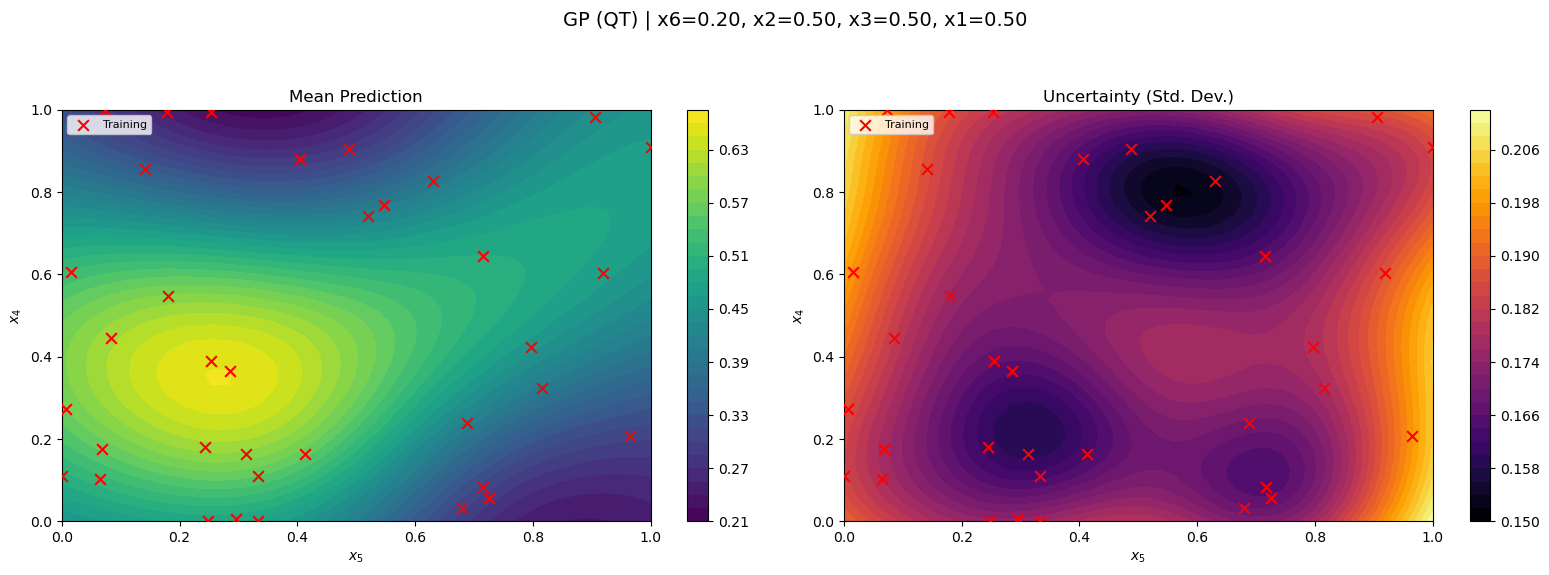

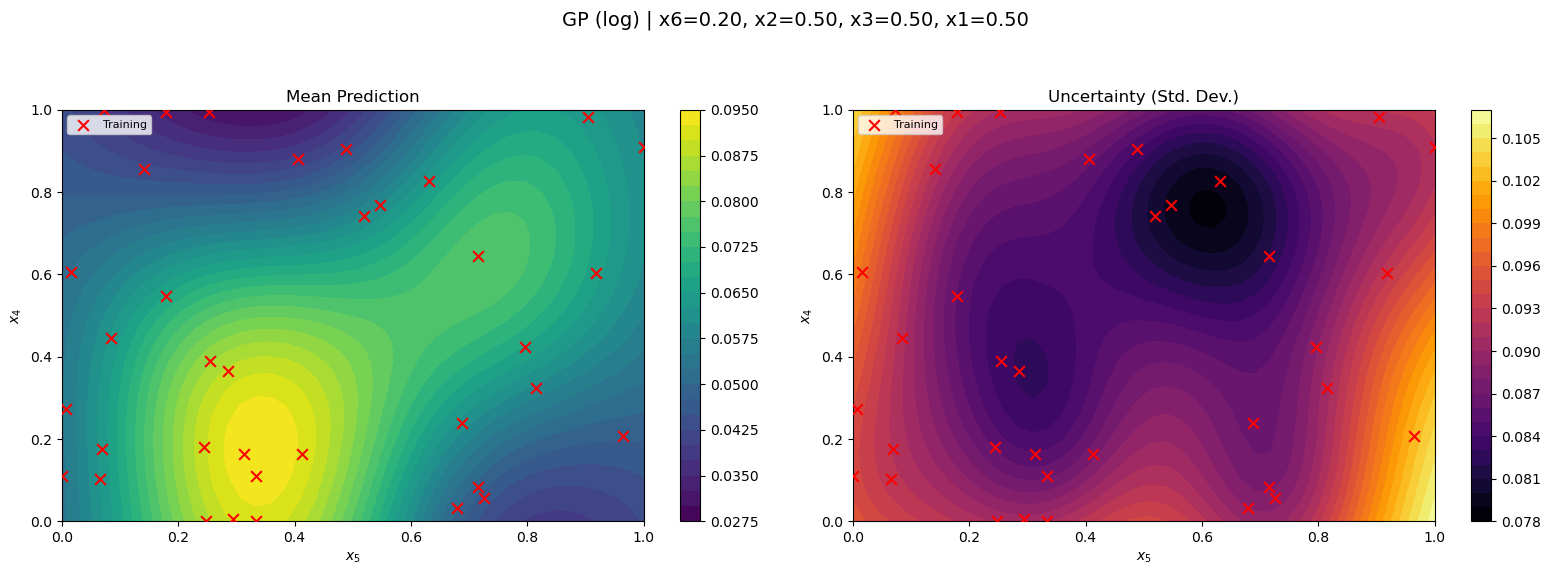

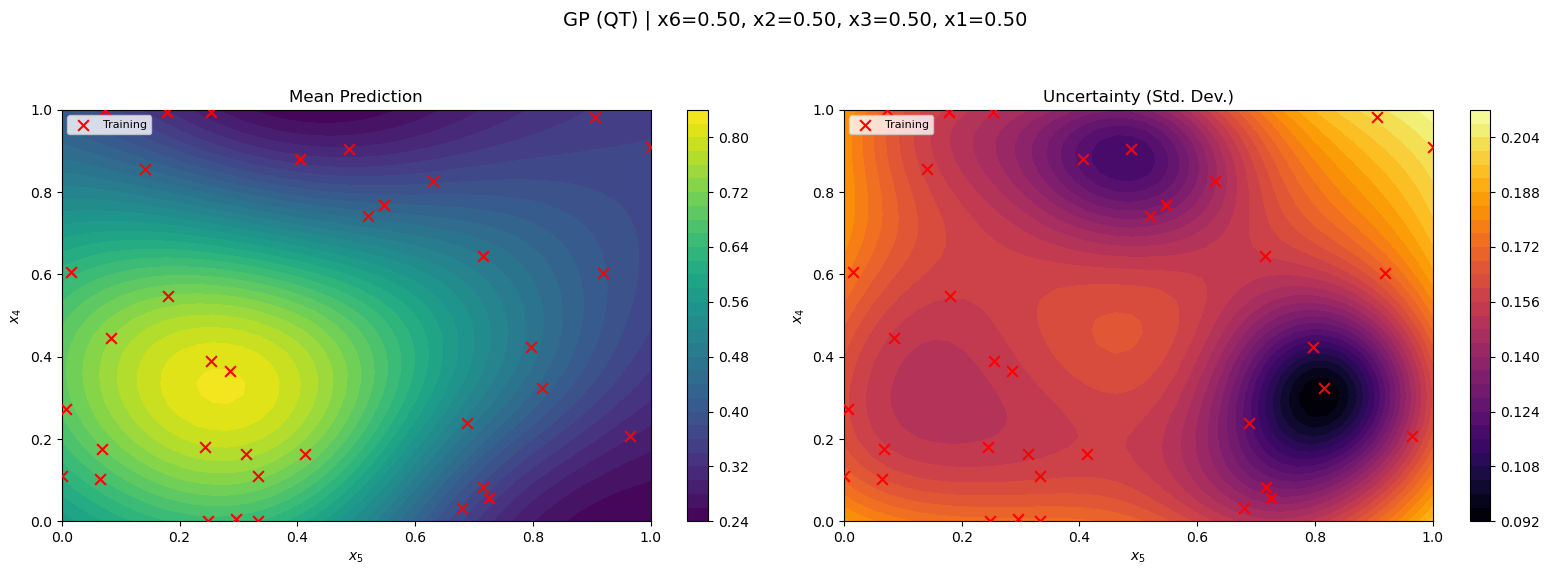

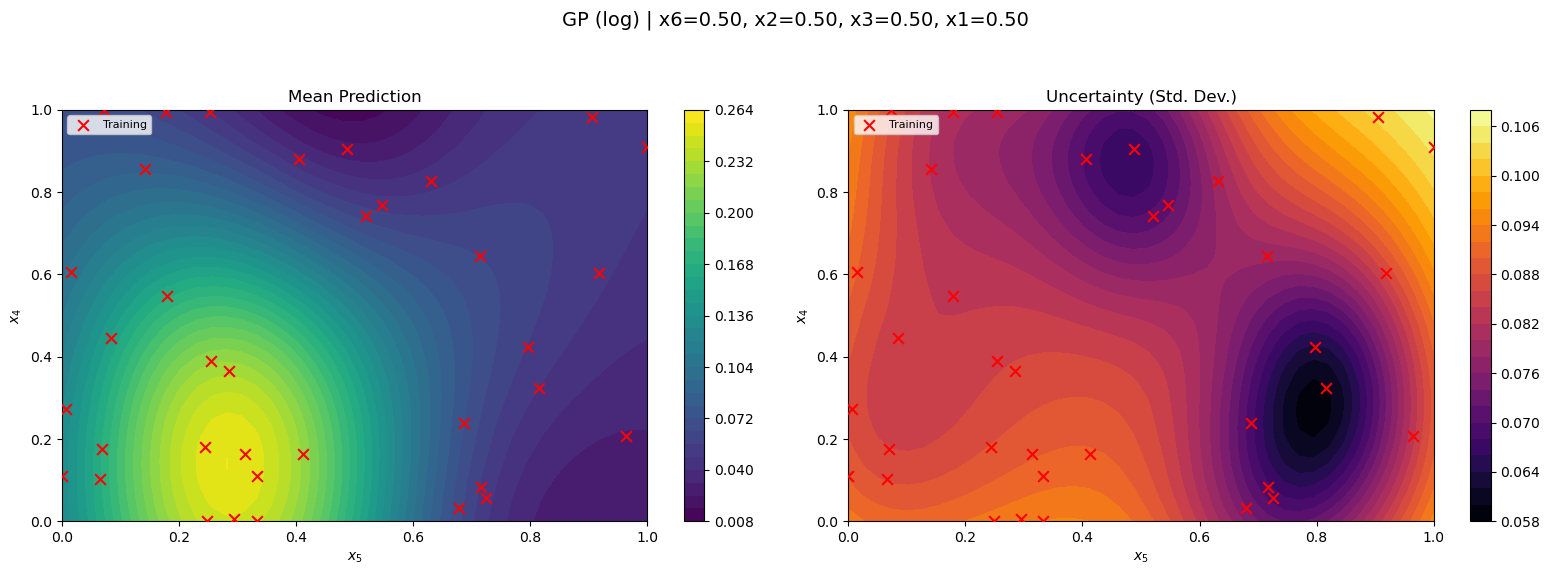

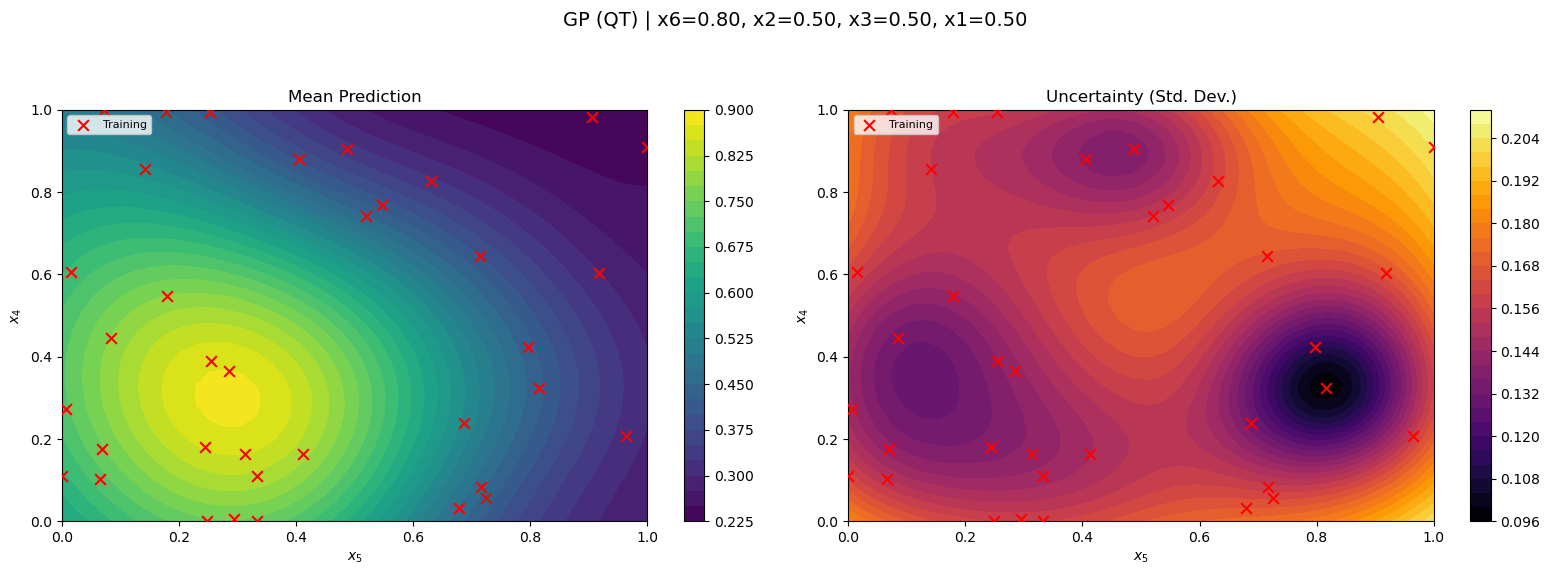

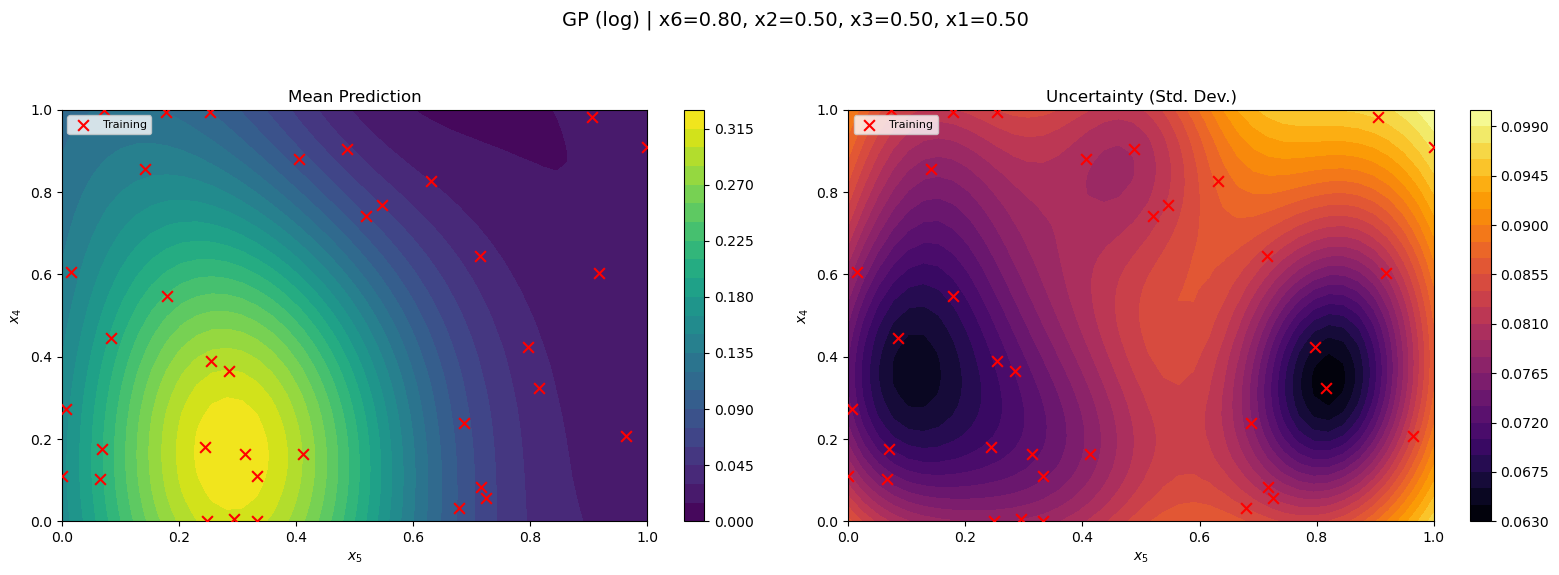

In [8]:
def plot_gp_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    mu_qt, sigma_qt = gp_predict(model_qt, likelihood_qt, grid_nd)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_qt.reshape(n_grid_2d, n_grid_2d),
        sigma_qt.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (QT)', fixed_info=fixed_info
    )

    mu_log, sigma_log = gp_predict(model_log, likelihood_log, grid_nd)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_log.reshape(n_grid_2d, n_grid_2d),
        sigma_log.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (log)', fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else 0.5) for d in slider_dims}
    plot_gp_slices(**kws)

# 4. SVM Analysis


=== Support Vectors: 32 / 36 training points ===
 Idx         Label        x1        x2        x3        x4        x5        x6         y_raw
   2           not    0.0908    0.6615    0.0659    0.2586    0.9635    0.6403      0.007503
   3           not    0.1189    0.6151    0.9058    0.8553    0.4136    0.5852      0.061424
   5           not    0.7649    0.2559    0.6091    0.2181    0.3229    0.0958      0.083747
   7           not    0.1953    0.0792    0.5546    0.1706    0.0149    0.1070      0.092645
   8           not    0.6423    0.8369    0.0218    0.1015    0.6831    0.6924      0.017870
   9           not    0.7899    0.1955    0.5756    0.0737    0.2590    0.0511      0.033565
  10           not    0.5285    0.4574    0.3601    0.3620    0.8169    0.6375      0.073516
  12           not    0.0757    0.3345    0.1327    0.6083    0.9184    0.8223      0.008826
  15           not    0.8171    0.5482    0.1033    0.1244    0.7282    0.4497      0.014798
  17           not  

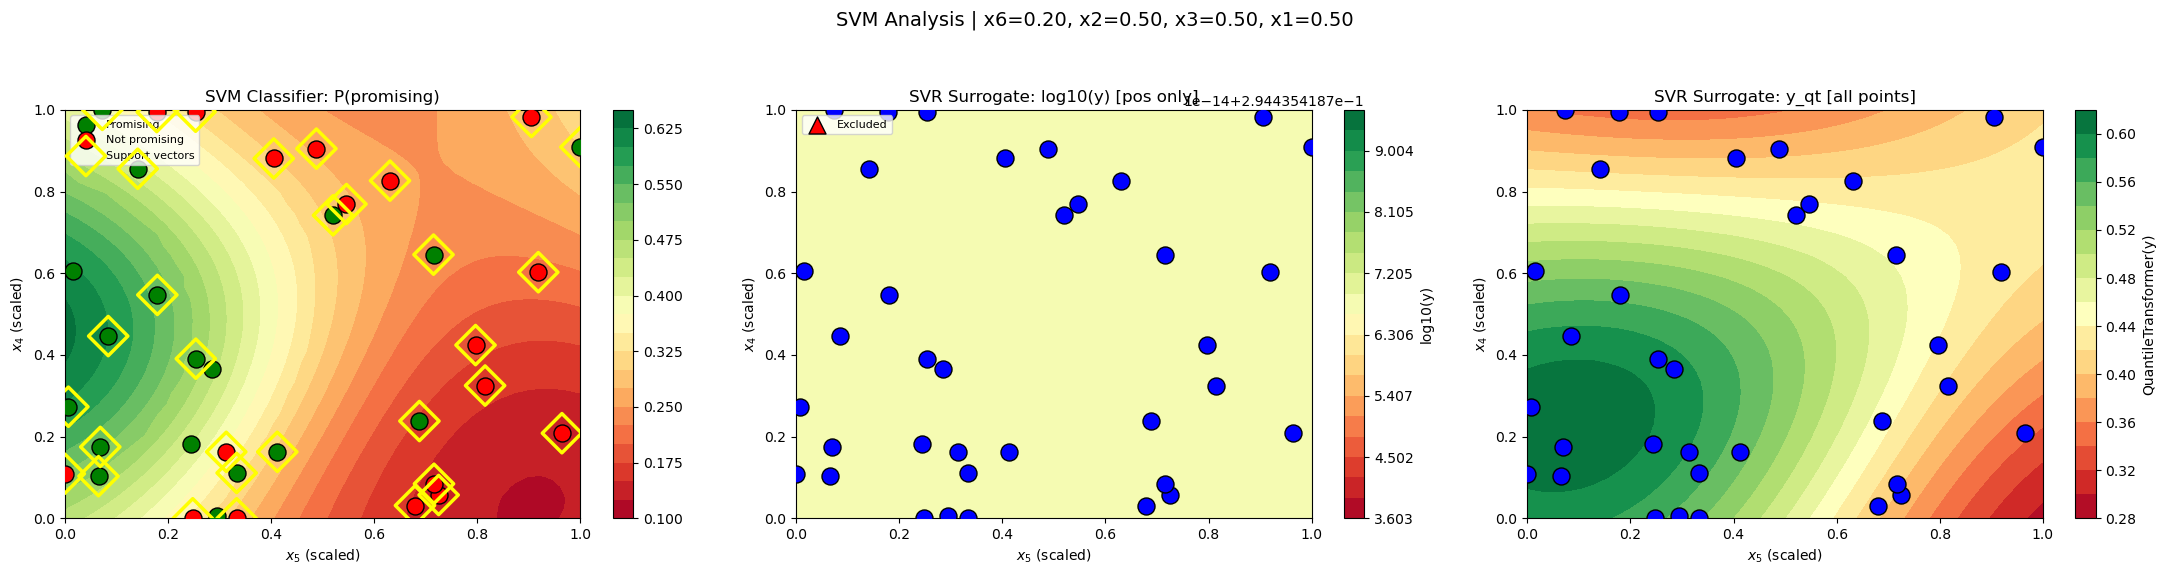

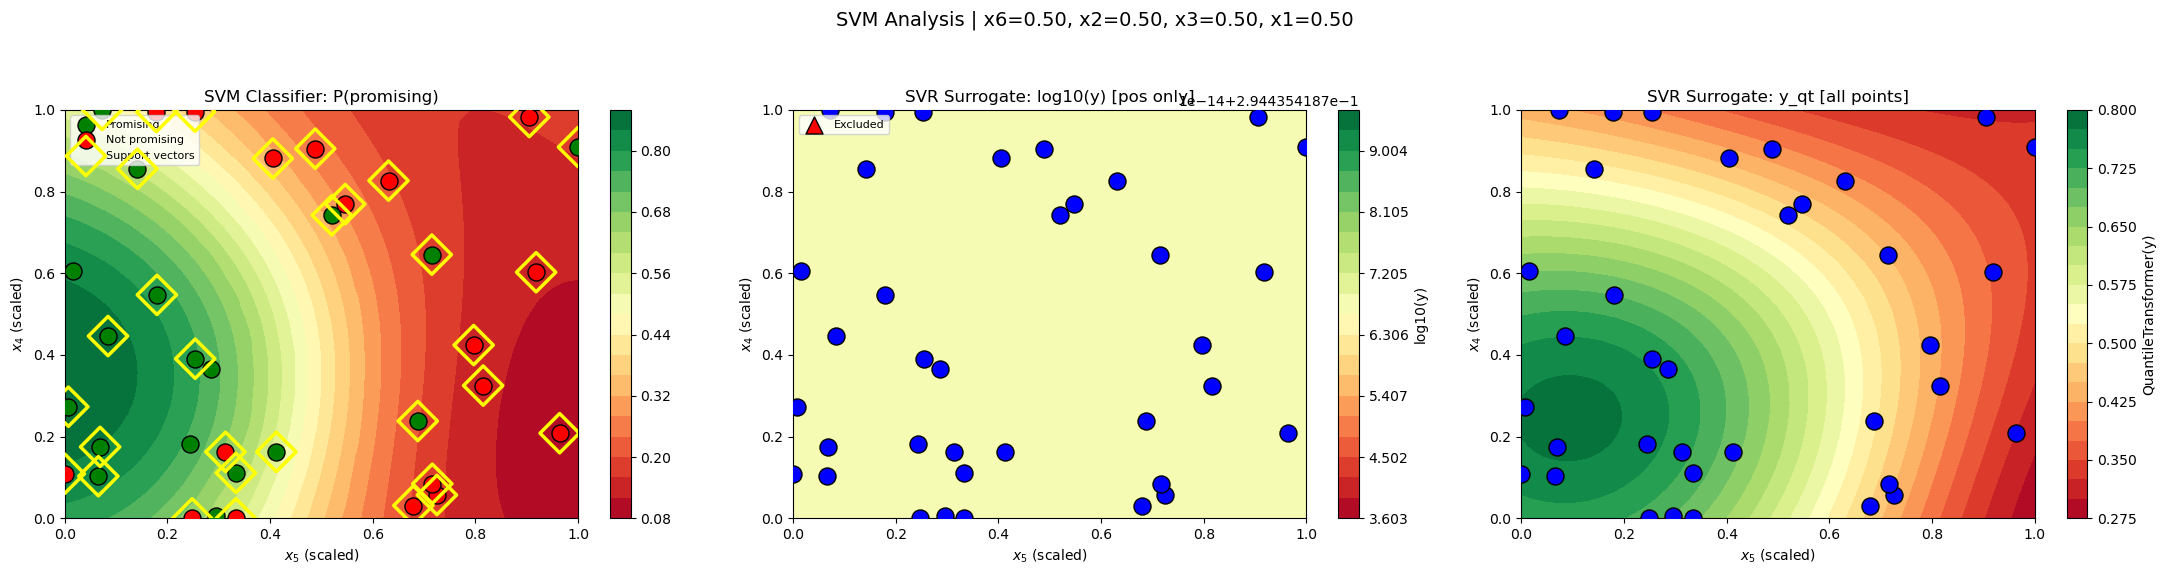

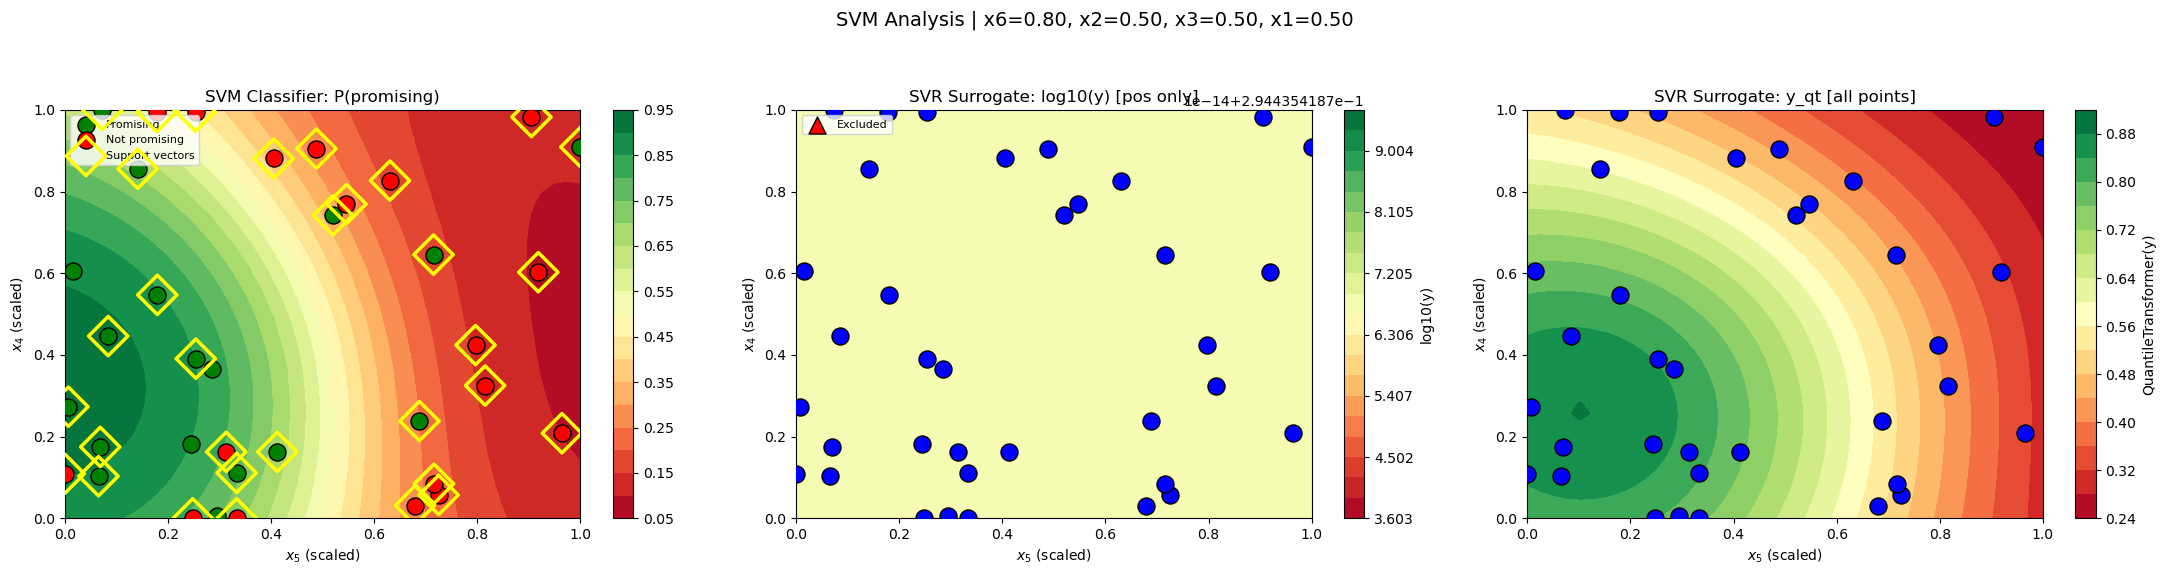

In [9]:
# SVM Classifier
# C=1 (soft margin): prevents decision boundary collapse in the 6D, 36-pt regime.
# gamma=2.0: between 'auto' (too broad → flat P) and 'scale' (too local → boundary collapse).
svm_labels = (y_log_pos > np.median(y_log_pos)).astype(int)

svm_clf = SVC(kernel='rbf', C=1, gamma=2.0, probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points ===")
print(f"{'Idx':>4}  {'Label':>12}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'x4':>8}  {'x5':>8}  {'x6':>8}  {'y_raw':>12}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    coords = "  ".join(f"{v:>8.4f}" for v in x_o)
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {coords}  {y_o:>12.6f}")

# SVR surrogates
svr_log = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.5)
svr_log.fit(X_train_pos, y_log_pos)

svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)

print(f"SVM labels: {svm_labels.sum()} promising, {(1-svm_labels).sum()} not promising")

# SVM slices
def plot_svm_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    svm_proba_slice = svm_clf.predict_proba(grid_nd)[:, 1]
    mu_svr_log_slice = svr_log.predict(grid_nd)
    mu_svr_qt_slice = svr_qt.predict(grid_nd)

    plot_nd_svm_analysis_slice(
        X1_plot, X2_plot,
        svm_proba_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_log_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_qt_slice.reshape(n_grid_2d, n_grid_2d),
        X_train, X_train_pos, X_train_neg, svm_labels,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info,
        support_vec_mask=support_vec_mask
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else 0.5) for d in slider_dims}
    plot_svm_slices(**kws)

# 5. Acquisition Function (SVM-constrained UCB Ensemble)

50,000 LHS candidates in [0,1]^6 for adequate coverage of the 6D space.

Noise dim: x3 (index 2), fixed at training mean = 0.4309
Active dims for acquisition: ['x1', 'x2', 'x4', 'x5', 'x6']
kappa = 3.6154 (week 7/13)

Gradient ascent: 64 starts × 200 steps (Adam lr=0.05)
UCB range across starts: [0.7985, 1.0886]


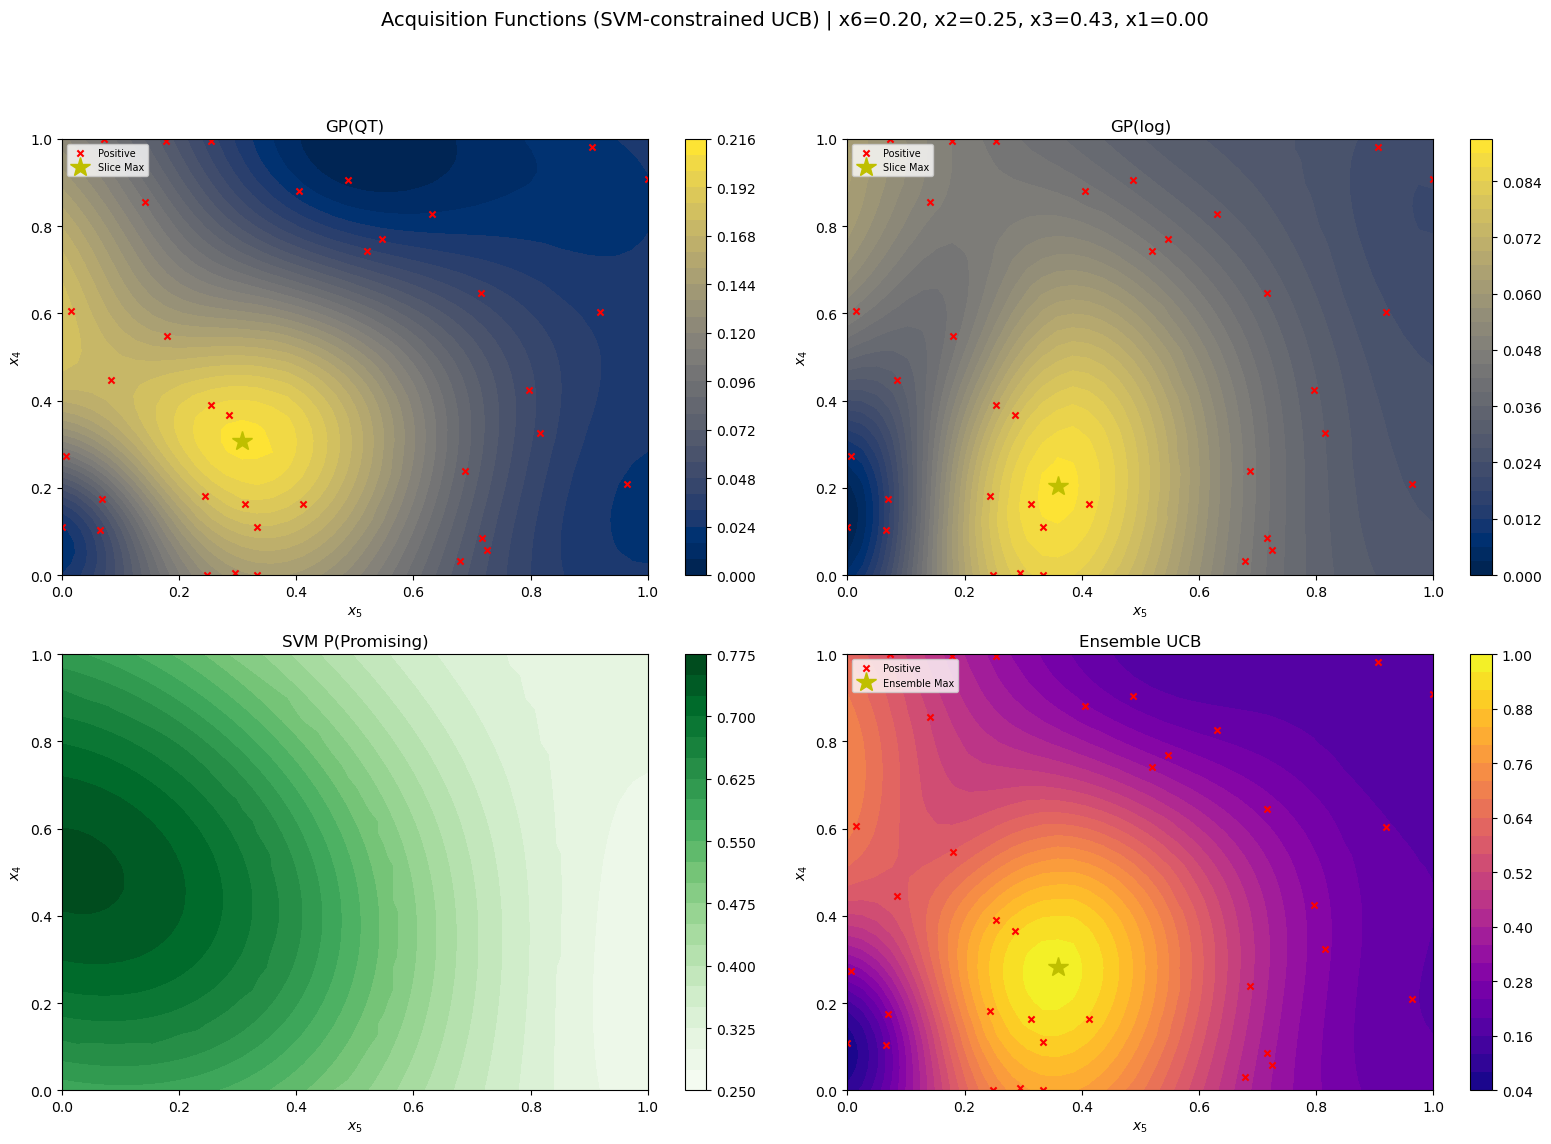

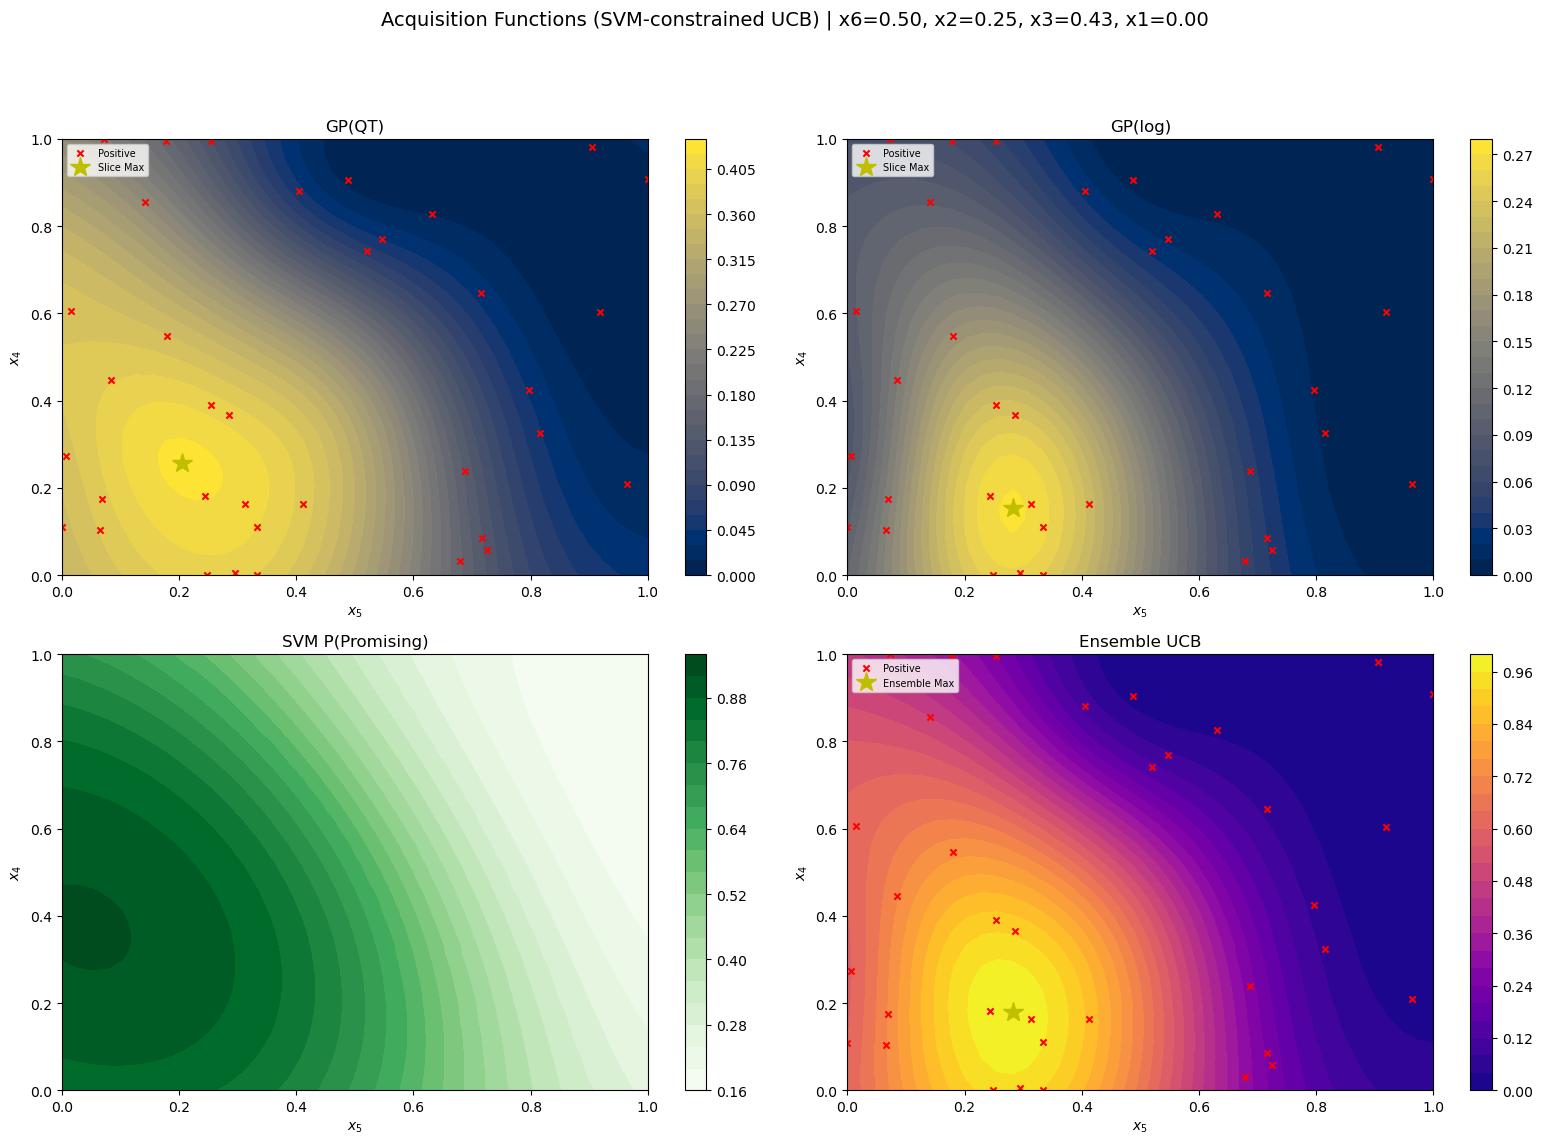

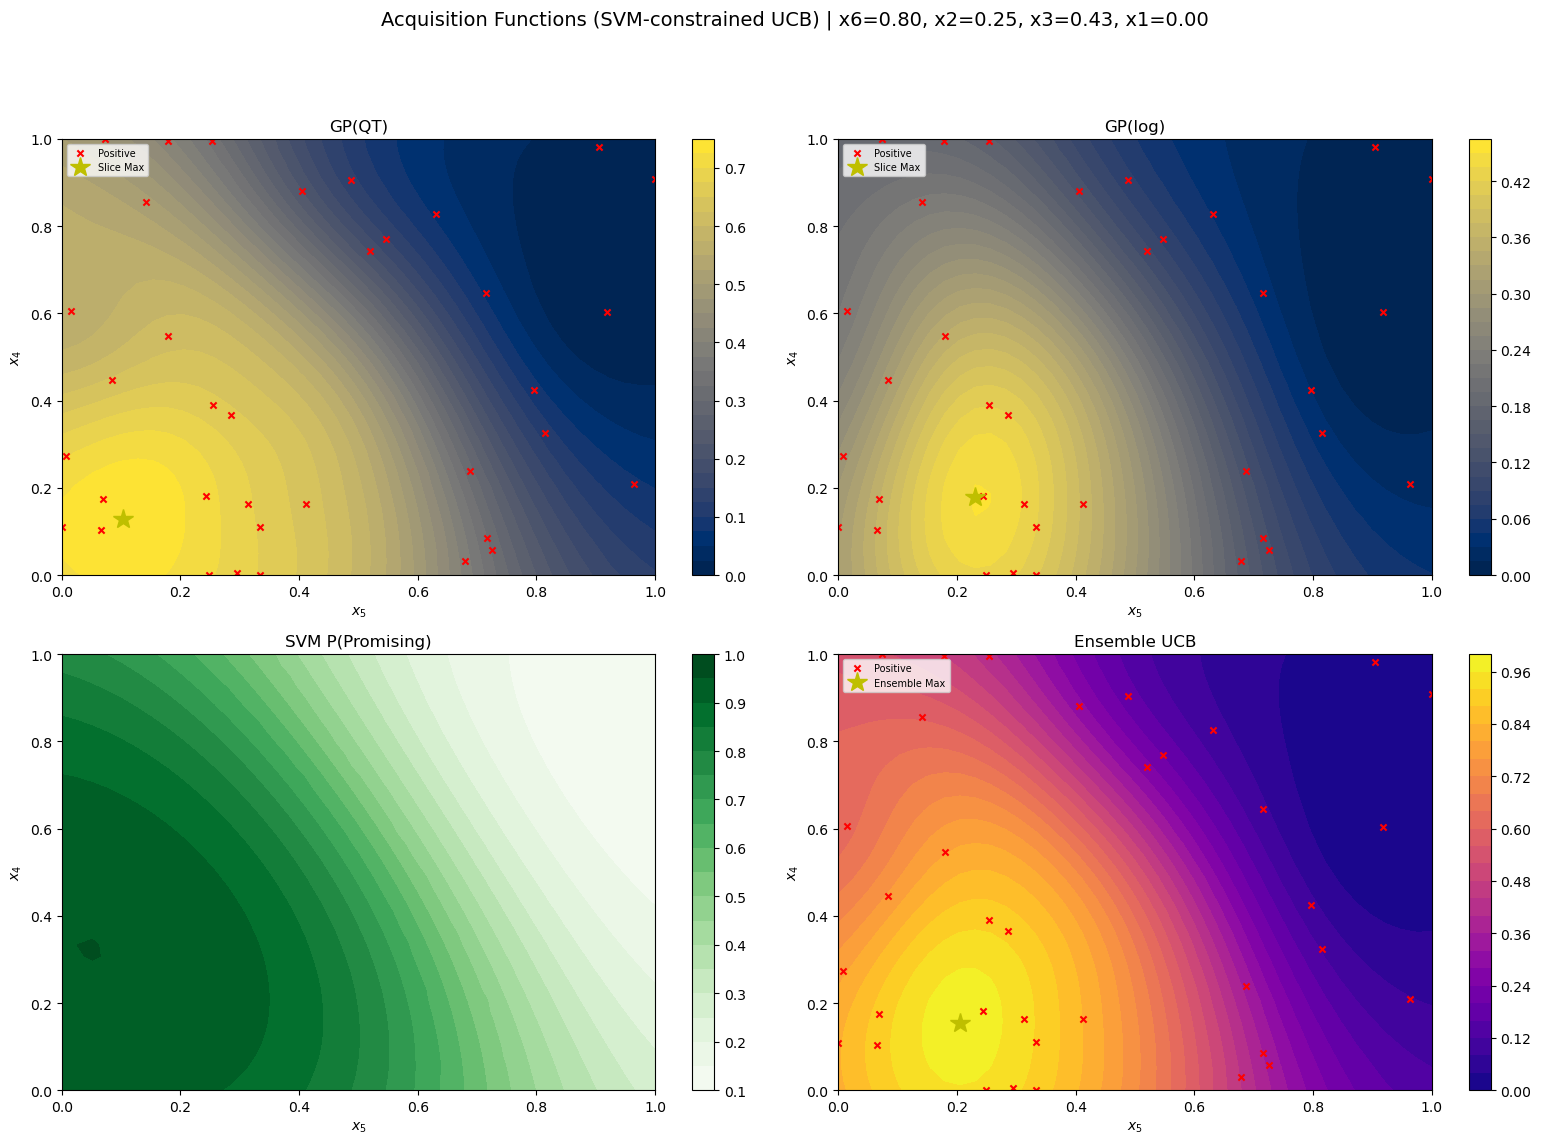

RECOMMENDED NEXT POINT (Gradient UCB, 64 starts × 200 steps, 5D active)
  Input (original space): [0.058114 0.24317  0.400488 0.147639 0.224165 0.724944]
  SVM P(promising):       0.925

Individual surrogate suggestions:
    GP (y_qt)           : [0.058114 0.24317  0.400488 0.147639 0.224165 0.724944] (SVM P=0.925)
    GP (y_log)          : [0.058114 0.24317  0.400488 0.147639 0.224165 0.724944] (SVM P=0.925)

Sanity check - is this a corner?
  x1 = 0.0002 <-- BOUNDARY!
  x2 = 0.2534 
  x3 = 0.4309 (noise dim, fixed at training mean)
  x4 = 0.0834 
  x5 = 0.2127 
  x6 = 0.7488 

Current best: [0.339751 0.104266 0.400488 0.234337 0.254864 0.687915] (y = 2.8567953850852152)

  SVM coverage (64 candidates): 89.1% promising
  SVM effective weights: SVM P(promising)

X_next = [0.0581144  0.24317026 0.40048783 0.14763854 0.22416466 0.72494437]

SUBMISSION: 0.058114-0.243170-0.400488-0.147639-0.224165-0.724944


In [10]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

def constrained_ucb(ucb_vals, svm_proba):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# Active subspace: search over 5D, fix noise dim at training mean
active_dims_acq = [d for d in range(n_dims) if d != noise_dim_idx]
n_active_acq = len(active_dims_acq)
x_noise_fixed = X_train[:, noise_dim_idx].mean()
print(f"Noise dim: x{noise_dim_idx+1} (index {noise_dim_idx}), fixed at training mean = {x_noise_fixed:.4f}")
print(f"Active dims for acquisition: {['x'+str(d+1) for d in active_dims_acq]}")

# Budget-aware kappa
WEEK = 7
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")

# --- Gradient-based UCB via Adam + sigmoid reparameterization ---
# x_active = sigmoid(z) maps R^n_active → (0,1)^n_active without box constraints.
# 64 LHS-seeded starts × 200 Adam steps; fast_pred_var disabled during loop for
# exact variance gradients; re-enabled for final evaluation.
N_STARTS = 64
N_STEPS  = 200
LR       = 0.05

seeds_lhs = LatinHypercube(d=n_active_acq, seed=0).random(n=N_STARTS)

model_qt.eval();  likelihood_qt.eval()
model_log.eval(); likelihood_log.eval()

cand_x_full  = []   # final full-dim (6D) candidate for each start
cand_ucb_raw = []   # ensemble UCB at final point (pre-SVM)

for seed_x in seeds_lhs:
    seed_x = np.clip(seed_x, 1e-4, 1 - 1e-4)
    z = torch.tensor(np.log(seed_x / (1 - seed_x)), dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=LR)

    for _ in range(N_STEPS):
        opt.zero_grad()
        x_active = torch.sigmoid(z)

        x_full_t = torch.zeros(n_dims, dtype=torch.float64)
        for j, od in enumerate(active_dims_acq):
            x_full_t[od] = x_active[j]
        x_full_t[noise_dim_idx] = float(x_noise_fixed)

        # Disable fast_pred_var during loop — exact variance required for valid gradients
        with gpytorch.settings.fast_pred_var(False):
            pq = likelihood_qt(model_qt(x_full_t.unsqueeze(0)))
            pl = likelihood_log(model_log(x_full_t.unsqueeze(0)))

        loss = -((pq.mean  + kappa * pq.variance.sqrt() +
                  pl.mean  + kappa * pl.variance.sqrt()) / 2.0)
        loss.backward()
        opt.step()

    # Final evaluation — re-enable fast_pred_var
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        x_f = torch.sigmoid(z).detach()
        x_full_np = np.zeros(n_dims)
        for j, od in enumerate(active_dims_acq):
            x_full_np[od] = x_f[j].item()
        x_full_np[noise_dim_idx] = x_noise_fixed

        x_t = torch.tensor(x_full_np.reshape(1, -1), dtype=torch.float64)
        pq_f = likelihood_qt(model_qt(x_t))
        pl_f = likelihood_log(model_log(x_t))
        ucb_val = ((pq_f.mean + kappa * pq_f.variance.sqrt() +
                    pl_f.mean + kappa * pl_f.variance.sqrt()) / 2.0).item()

    cand_x_full.append(x_full_np)
    cand_ucb_raw.append(ucb_val)

X_grad_cands = np.array(cand_x_full)
ucb_arr      = np.array(cand_ucb_raw)
print(f"\nGradient ascent: {N_STARTS} starts × {N_STEPS} steps (Adam lr={LR})")
print(f"UCB range across starts: [{ucb_arr.min():.4f}, {ucb_arr.max():.4f}]")

# Apply SVM constraint on the 64 final candidates
svm_proba = svm_clf.predict_proba(X_grad_cands)[:, 1]
if (svm_proba > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of gradient candidates as promising — applying fail-safe.")
    svm_proba_effective = np.ones(N_STARTS)
else:
    svm_proba_effective = svm_proba

ucb_shifted = ucb_arr - ucb_arr.min() + 1e-6
constrained_scores = ucb_shifted * svm_proba_effective

best_ensemble_idx = np.argmax(constrained_scores)
x_next_norm = X_grad_cands[best_ensemble_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Per-surrogate bests (both used same gradient trajectory — report ensemble best)
best_points = {}
for name in ['GP (y_qt)', 'GP (y_log)']:
    best_points[name] = {
        'idx': best_ensemble_idx,
        'norm': x_next_norm,
        'orig': x_next_orig,
        'svm_p': svm_proba[best_ensemble_idx]
    }

# --- Acquisition visualization (per-slice grid, same as original) ---
def plot_acq_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    mu_qt_s,  sigma_qt_s  = gp_predict(model_qt,  likelihood_qt,  grid_nd)
    mu_log_s, sigma_log_s = gp_predict(model_log, likelihood_log, grid_nd)
    svm_p_s = svm_clf.predict_proba(grid_nd)[:, 1]

    ucb_qt_s  = constrained_ucb(upper_confidence_bound(mu_qt_s,  sigma_qt_s,  kappa), svm_p_s)
    ucb_log_s = constrained_ucb(upper_confidence_bound(mu_log_s, sigma_log_s, kappa), svm_p_s)
    ens_s = (normalize_01(ucb_qt_s) + normalize_01(ucb_log_s)) / 2.0

    shape = (n_grid_2d, n_grid_2d)
    plot_nd_acquisition_comparison_slice(
        X1_plot, X2_plot,
        {'GP(QT)': ucb_qt_s.reshape(shape), 'GP(log)': ucb_log_s.reshape(shape)},
        svm_p_s.reshape(shape), ens_s.reshape(shape),
        X_train_pos, X_train_neg,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else float(x_next_norm[d])) for d in slider_dims}
    plot_acq_slices(**kws)

# Summary
print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (Gradient UCB, {N_STARTS} starts × {N_STEPS} steps, {n_active_acq}D active)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\nIndividual surrogate suggestions:")
for name, bp in best_points.items():
    print(f"    {name:20s}: {np.array_str(bp['orig'], precision=6)} (SVM P={bp['svm_p']:.3f})")

print(f"\nSanity check - is this a corner?")
for i in range(n_dims):
    if i == noise_dim_idx:
        print(f"  x{i+1} = {x_next_norm[i]:.4f} (noise dim, fixed at training mean)")
    else:
        at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
        print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max()})")
print(f"\n  SVM coverage (64 candidates): {(svm_proba > 0.5).mean()*100:.1f}% promising")
print(f"  SVM effective weights: {'uniform (fail-safe)' if (svm_proba > 0.5).mean() < 0.05 else 'SVM P(promising)'}")

X_next = x_next_orig
print(f"\nX_next = {X_next}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")